# 02 · Data Preprocessing
**CalixAI — Smart Calisthenics Assistant**  
Encodes, scales, and prepares features for each of the three models.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

df = pd.read_csv('../data/raw/calisthenics_dataset.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head(3)

Shape: (12000, 19)
Columns: ['age', 'gender', 'height_cm', 'weight_kg', 'bmi', 'fitness_level', 'goal', 'exercise', 'duration_min', 'intensity', 'sets', 'reps', 'heart_rate_avg', 'training_volume', 'effort_score', 'metabolic_proxy', 'hr_reserve_ratio', 'calories_burned', 'meal_plan']


,age,gender,height_cm,weight_kg,bmi,fitness_level,goal,exercise,duration_min,intensity,sets,reps,heart_rate_avg,training_volume,effort_score,metabolic_proxy,hr_reserve_ratio,calories_burned,meal_plan
0,57,Male,167.7,96.8,34.42,Beginner,Fat Loss,Squats,21,Medium,4,16,131,64,84,1.669,0.804,217.4,fl_beginner
1,50,Male,176.5,95.1,30.53,Beginner,Muscle Gain,Push-ups,39,Medium,5,11,135,55,195,1.865,0.794,347.8,mg_beginner
2,23,Female,158.4,79.4,31.65,Beginner,Muscle Gain,Squats,33,Low,4,7,134,28,132,3.308,0.680,202.0,mg_beginner


## 1. Duplicate & Missing Value Check

In [14]:
print('Duplicates:', df.duplicated().sum())
print('\nNull counts:')
print(df.isnull().sum())
print('\nDtypes:')
print(df.dtypes)

Duplicates: 0

Null counts:
age                 0
gender              0
height_cm           0
weight_kg           0
bmi                 0
fitness_level       0
goal                0
exercise            0
duration_min        0
intensity           0
sets                0
reps                0
heart_rate_avg      0
training_volume     0
effort_score        0
metabolic_proxy     0
hr_reserve_ratio    0
calories_burned     0
meal_plan           0
dtype: int64

Dtypes:
age                   int64
gender                  str
height_cm           float64
weight_kg           float64
bmi                 float64
fitness_level           str
goal                    str
exercise                str
duration_min          int64
intensity               str
sets                  int64
reps                  int64
heart_rate_avg        int64
training_volume       int64
effort_score          int64
metabolic_proxy     float64
hr_reserve_ratio    float64
calories_burned     float64
meal_plan               str


## 2. Label Encoding
Categorical columns are encoded using `LabelEncoder`. The same encoders saved in notebook 00 are used here for consistency.

In [15]:
data = df.copy()

cat_cols = ['gender', 'goal', 'fitness_level', 'exercise', 'intensity']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col + '_enc'] = le.fit_transform(data[col].astype(str))
    encoders[col] = le
    print(f'  {col}: {list(le.classes_)}')

# Interaction features used by exercise and meal plan models
data['fl_goal_combo']      = data['fitness_level_enc'] * 10 + data['goal_enc']
data['fl_intensity_combo'] = data['fitness_level_enc'] * 10 + data['intensity_enc']
data['bmi_group']          = data['bmi'].apply(lambda b: 0 if b<18.5 else 1 if b<25 else 2 if b<30 else 3)

print('\nEncoded columns added:', [c for c in data.columns if '_enc' in c or c in ['fl_goal_combo','fl_intensity_combo','bmi_group']])

  gender: ['Female', 'Male']
  goal: ['Fat Loss', 'Maintenance', 'Muscle Gain']
  fitness_level: ['Advanced', 'Beginner', 'Intermediate']
  exercise: ['Dips', 'Handstand', 'L-sit', 'Muscle-ups', 'Plank', 'Pull-ups', 'Push-ups', 'Squats']
  intensity: ['High', 'Low', 'Medium']

Encoded columns added: ['gender_enc', 'goal_enc', 'fitness_level_enc', 'exercise_enc', 'intensity_enc', 'fl_goal_combo', 'fl_intensity_combo', 'bmi_group']


## 3. Calorie Model Features (16 features)

Feature matrix : (12000, 16)
Target range   : 32.4 – 2869.7 kcal
Target mean    : 425.5 kcal


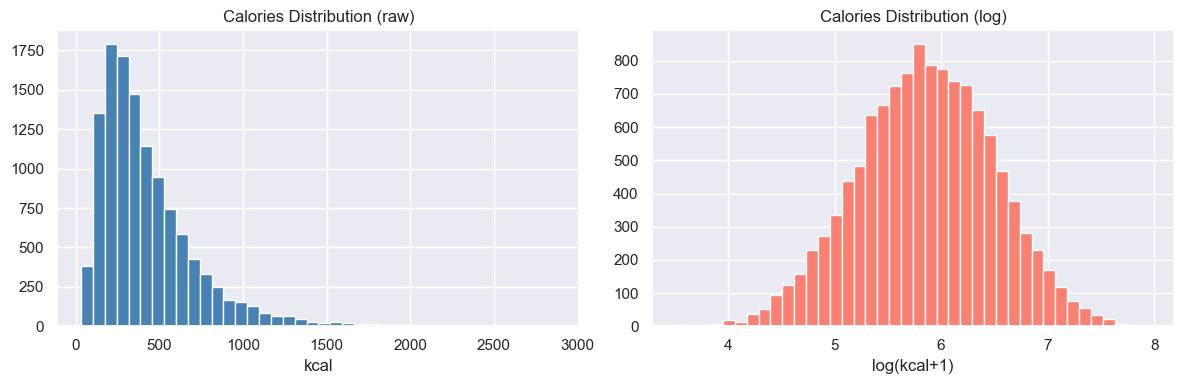

In [16]:
CAL_FEATURES = [
    'age', 'gender_enc', 'height_cm', 'weight_kg', 'bmi',
    'fitness_level_enc', 'exercise_enc', 'duration_min', 'intensity_enc',
    'sets', 'reps', 'heart_rate_avg', 'training_volume', 'effort_score',
    'metabolic_proxy', 'hr_reserve_ratio',
]

X_cal = data[CAL_FEATURES]
y_cal = data['calories_burned']

scaler_cal = StandardScaler()
X_cal_scaled = scaler_cal.fit_transform(X_cal)

print(f'Feature matrix : {X_cal_scaled.shape}')
print(f'Target range   : {y_cal.min():.1f} – {y_cal.max():.1f} kcal')
print(f'Target mean    : {y_cal.mean():.1f} kcal')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_cal, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Calories Distribution (raw)')
axes[0].set_xlabel('kcal')
axes[1].hist(np.log1p(y_cal), bins=40, color='salmon', edgecolor='white')
axes[1].set_title('Calories Distribution (log)')
axes[1].set_xlabel('log(kcal+1)')
plt.tight_layout()
plt.show()

## 4. Exercise Model Features (10 features)

Feature matrix : (12000, 10)
Classes        : ['Dips', 'Handstand', 'L-sit', 'Muscle-ups', 'Plank', 'Pull-ups', 'Push-ups', 'Squats']

Class balance:
exercise
Push-ups      3185
Pull-ups      2449
Squats        2436
Dips          1242
Plank          883
Muscle-ups     657
L-sit          586
Handstand      562


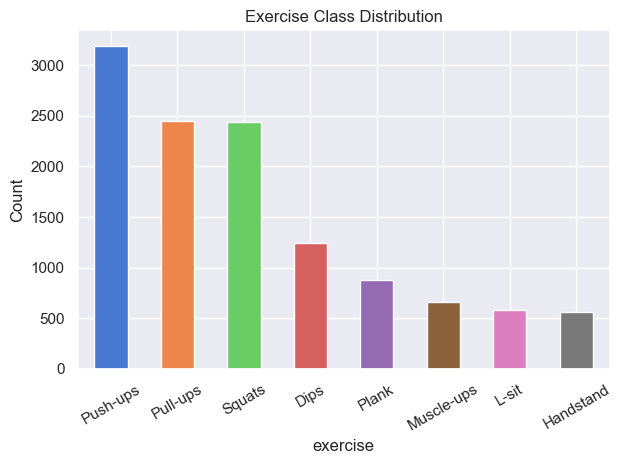

In [17]:
EX_FEATURES = [
    'age', 'gender_enc', 'weight_kg', 'bmi',
    'fitness_level_enc', 'goal_enc', 'intensity_enc',
    'heart_rate_avg', 'fl_goal_combo', 'fl_intensity_combo',
]

X_ex = data[EX_FEATURES]
y_ex = data['exercise_enc']

scaler_ex = StandardScaler()
X_ex_scaled = scaler_ex.fit_transform(X_ex)

print(f'Feature matrix : {X_ex_scaled.shape}')
print(f'Classes        : {list(encoders["exercise"].classes_)}')
print('\nClass balance:')
balance = data['exercise'].value_counts()
print(balance.to_string())

balance.plot(kind='bar', color=sns.color_palette('muted', len(balance)))
plt.title('Exercise Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Meal Plan Model Features (11 features)

Feature matrix : (12000, 11)
Classes        : ['fl_advanced', 'fl_beginner', 'fl_intermediate', 'mg_advanced', 'mg_beginner', 'mg_intermediate', 'mt_standard']

Class balance:
meal_plan
mt_standard        2374
mg_beginner        2282
fl_beginner        2071
mg_intermediate    1795
fl_intermediate    1584
mg_advanced        1006
fl_advanced         888


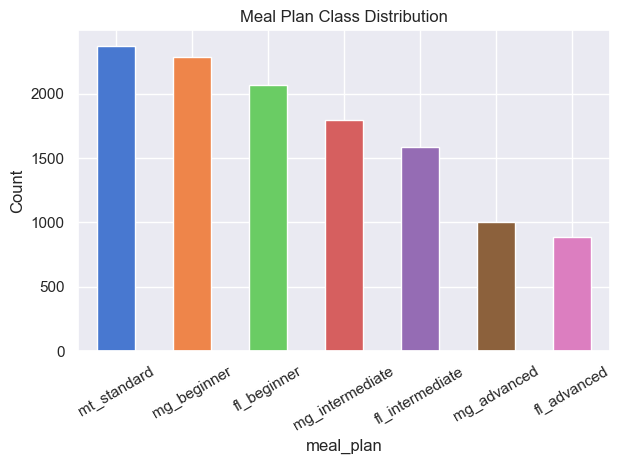

In [18]:
MP_FEATURES = [
    'age', 'gender_enc', 'height_cm', 'weight_kg', 'bmi',
    'fitness_level_enc', 'goal_enc', 'intensity_enc',
    'calories_burned', 'fl_goal_combo', 'bmi_group',
]

mp_le = LabelEncoder()
y_mp  = mp_le.fit_transform(data['meal_plan'].astype(str))

X_mp = data[MP_FEATURES]
scaler_mp = StandardScaler()
X_mp_scaled = scaler_mp.fit_transform(X_mp)

print(f'Feature matrix : {X_mp_scaled.shape}')
print(f'Classes        : {list(mp_le.classes_)}')
print('\nClass balance:')
mp_balance = data['meal_plan'].value_counts()
print(mp_balance.to_string())

mp_balance.plot(kind='bar', color=sns.color_palette('muted', len(mp_balance)))
plt.title('Meal Plan Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Feature Summary

In [19]:
summary = pd.DataFrame([
    {'Model': 'Calorie Prediction',  'Features': len(CAL_FEATURES), 'Target': 'calories_burned (continuous)', 'Type': 'Regression'},
    {'Model': 'Exercise Suggestion', 'Features': len(EX_FEATURES),  'Target': f'exercise ({len(encoders["exercise"].classes_)} classes)', 'Type': 'Classification'},
    {'Model': 'Meal Plan',           'Features': len(MP_FEATURES),  'Target': f'meal_plan ({len(mp_le.classes_)} classes)', 'Type': 'Classification'},
])
print(summary.to_string(index=False))
print('\nPreprocessing complete. Run notebooks 03 → 05 to train each model.')

              Model  Features                       Target           Type
 Calorie Prediction        16 calories_burned (continuous)     Regression
Exercise Suggestion        10         exercise (8 classes) Classification
          Meal Plan        11        meal_plan (7 classes) Classification

Preprocessing complete. Run notebooks 03 → 05 to train each model.
